# Load a MegaScene Reconstruction

In [1]:
import pycolmap
from pathlib import Path

# Set these values for where the data is saved, and what scene you want to load
ROOT_DATA_DIR = Path(r'C:\Users\jackd\data\MegaScenes')
MEGASCENE_ID = ('000','000')

# Define paths to get to data
db_path     = ROOT_DATA_DIR / "databases" / "main" / MEGASCENE_ID[0] / MEGASCENE_ID[1] / "database.db"
model_path  = ROOT_DATA_DIR / "reconstruct"        / MEGASCENE_ID[0] / MEGASCENE_ID[1] / "colmap" / "0"
images_path = ROOT_DATA_DIR / "images"             / MEGASCENE_ID[0] / MEGASCENE_ID[1] 

In [2]:
# Load reconstruction
reconstruction = pycolmap.Reconstruction(model_path)

# Print basic info about the reconstruction
print(f"Number of registered images: {len(reconstruction.images)}")
print(f"Number of 3D points: {len(reconstruction.points3D)}")

Number of registered images: 15
Number of 3D points: 2321


In [3]:
# Load the database
db = pycolmap.Database(db_path)

# Print some basic info about the database
print(f"Number of images in database {db.num_images}")

Number of images in database 37


# Plot the graph of data

Text(0.5, 1.0, 'Image-Point Bipartite Graph (shared layout)')

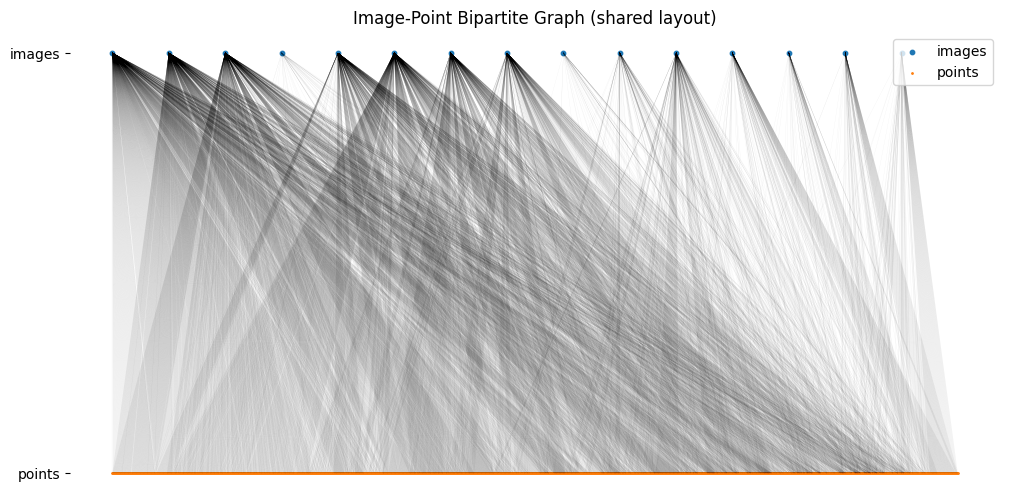

In [7]:
import numpy as np, matplotlib.pyplot as plt

# Choose layout:
#   'bands'  -> images in [0,0.48), points in [0.52,1.0] (clear separation)
#   'shared' -> both images and points spread across [0,1) using simple barycentric ordering
LAYOUT_MODE = 'shared'  # 'bands' or 'shared'
MAX_NEIGHBORS_PER_NODE = 200  # cap neighbors used in ordering for speed
N_ORDER_ITERS = 2             # barycentric refinement iterations

# Collect image and point ids
imgs = list(reconstruction.images.values())
pts_ids = list(reconstruction.points3D.keys())

# Index maps
ix = {im.image_id: i for i, im in enumerate(imgs)}
px = {pid: j for j, pid in enumerate(pts_ids)}

n_i, n_p = len(imgs), len(pts_ids)

# Build sparse adjacency lists between images and points
img_to_pts = [[] for _ in range(n_i)]
pt_to_imgs = [[] for _ in range(n_p)]
for im in imgs:
    i = ix[im.image_id]
    for p2d in im.points2D:
        pid = p2d.point3D_id
        if pid != -1 and pid in px:
            j = px[pid]
            # Only keep up to MAX_NEIGHBORS_PER_NODE to bound cost
            if len(img_to_pts[i]) < MAX_NEIGHBORS_PER_NODE:
                img_to_pts[i].append(j)
            if len(pt_to_imgs[j]) < MAX_NEIGHBORS_PER_NODE:
                pt_to_imgs[j].append(i)

if LAYOUT_MODE == 'bands' or n_i == 0 or n_p == 0:
    # Lay out images and points into two horizontal bands on the x-axis
    left_max = 0.48   # images occupy [0.00, 0.48)
    right_min = 0.52  # points  occupy [0.52, 1.00]

    Xi = np.linspace(0.0, left_max, max(n_i, 1), endpoint=False)[:n_i] if n_i > 0 else np.array([])
    Xp = np.linspace(right_min, 1.0,  max(n_p, 1), endpoint=False)[:n_p] if n_p > 0 else np.array([])
else:
    # Shared-range barycentric layout: both sets fill [0,1)
    Xi = np.linspace(0.0, 1.0, max(n_i, 1), endpoint=False)[:n_i] if n_i > 0 else np.array([])
    Xp = np.linspace(0.0, 1.0, max(n_p, 1), endpoint=False)[:n_p] if n_p > 0 else np.array([])

    for _ in range(N_ORDER_ITERS):
        # Reorder images by the barycenter of their connected points
        if n_i > 0:
            scores_i = np.empty(n_i, dtype=float)
            for i in range(n_i):
                nbrs = img_to_pts[i]
                scores_i[i] = np.mean(Xp[nbrs]) if len(nbrs) else Xi[i]
            order_i = np.argsort(scores_i)
            Xi_new = np.empty_like(Xi)
            Xi_new[order_i] = np.linspace(0.0, 1.0, n_i, endpoint=False)
            Xi = Xi_new
        # Reorder points by the barycenter of their connected images
        if n_p > 0:
            scores_p = np.empty(n_p, dtype=float)
            for j in range(n_p):
                nbrs = pt_to_imgs[j]
                scores_p[j] = np.mean(Xi[nbrs]) if len(nbrs) else Xp[j]
            order_p = np.argsort(scores_p)
            Xp_new = np.empty_like(Xp)
            Xp_new[order_p] = np.linspace(0.0, 1.0, n_p, endpoint=False)
            Xp = Xp_new

# y positions: images on top line, points on bottom line
y_img = np.ones(n_i)
y_pts = np.zeros(n_p)

plt.figure(figsize=(12, 6))
plt.scatter(Xi, y_img, s=10, c='tab:blue', label='images')
plt.scatter(Xp, y_pts, s=1,  c='tab:orange', label='points')

# Draw edges between each image and its observed 3D points
for im in imgs:
    x1 = Xi[ix[im.image_id]]
    for p2d in im.points2D:
        pid = p2d.point3D_id
        if pid != -1 and pid in px:
            x2 = Xp[px[pid]]
            plt.plot([x1, x2], [1, 0], c='k', lw=0.2, alpha=0.06)

plt.yticks([0, 1], ["points", "images"]) 
plt.xticks([])
plt.xlim(-0.05, 1.05)
plt.box(False)
plt.legend(loc='upper right')
plt.title(f"Image-Point Bipartite Graph ({'shared' if LAYOUT_MODE=='shared' else 'banded'} layout)")


Text(0.5, 0.92, '3D Nodes')

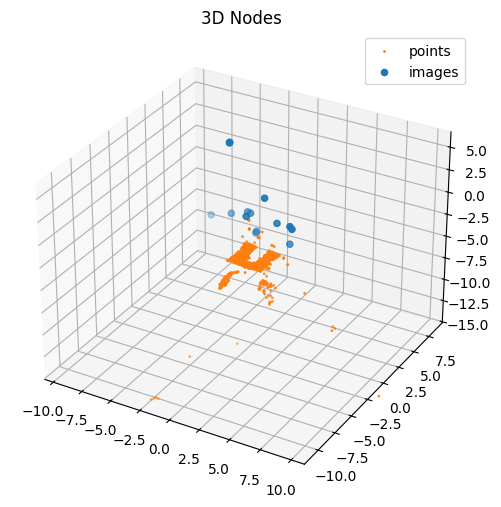

In [27]:
import numpy as np, matplotlib.pyplot as plt

imgs = list(reconstruction.images.values())
cams = np.array([im.projection_center() for im in imgs])
pts  = np.array([p.xyz for p in reconstruction.points3D.values()])

ax = plt.figure(figsize=(8,6)).add_subplot(111, projection='3d')
ax.scatter(*pts.T, s=1, c='tab:orange', label='points')
ax.scatter(*cams.T, s=20, c='tab:blue', label='images')
P = np.vstack([pts, cams]) ; c = np.median(P,0) ; lo,hi = np.percentile(P,(10,90),0) ; r = (hi-lo).max()/2
lC,hC = np.percentile(cams,(2.5,97.5),0) ; r = max(r, np.abs(np.vstack([hC-c, c-lC])).max())
ax.set(xlim=(c[0]-r, c[0]+r), ylim=(c[1]-r, c[1]+r), zlim=(c[2]-r, c[2]+r))
ax.legend(); ax.set_title('3D Nodes')


In [35]:
import numpy as np, plotly.graph_objects as go

imgs = list(reconstruction.images.values())
cams = np.array([im.projection_center() for im in imgs])
pts  = np.array([p.xyz for p in reconstruction.points3D.values()])

P = np.vstack([pts, cams]) ; c = np.median(P,0) ; lo,hi = np.percentile(P,(10,90),0) ; r = (hi-lo).max()/2
lC,hC = np.percentile(cams,(2.5,97.5),0) ; r = max(r, np.abs(np.vstack([hC-c, c-lC])).max())

fig = go.Figure([
    go.Scatter3d(x=pts[:,0],  y=pts[:,1],  z=pts[:,2],  mode='markers', name='points', marker=dict(size=1, color='orange')),
    go.Scatter3d(x=cams[:,0], y=cams[:,1], z=cams[:,2], mode='markers', name='images', marker=dict(size=4, color='blue'))
])

SAMPLE, N_IMGS, N_EDGES = True, 5, 10000
ims = imgs if not SAMPLE else imgs[:min(N_IMGS, len(imgs))]
X=Y=Z=[]
for im in ims:
    c0 = im.projection_center()
    for p2d in im.points2D:
        pid = p2d.point3D_id
        if pid in reconstruction.points3D:
            q = reconstruction.points3D[pid].xyz
            X += [c0[0], q[0], None]; Y += [c0[1], q[1], None]; Z += [c0[2], q[2], None]
            if SAMPLE and len(X)//3 >= N_EDGES: break
    if SAMPLE and len(X)//3 >= N_EDGES: break
fig.add_trace(go.Scatter3d(x=X, y=Y, z=Z, mode='lines', name='edges', line=dict(width=1, color='rgba(0,0,0,0.15)')))

fig.update_layout(scene=dict(
    xaxis=dict(range=[c[0]-r, c[0]+r]),
    yaxis=dict(range=[c[1]-r, c[1]+r]),
    zaxis=dict(range=[c[2]-r, c[2]+r]),
    aspectmode='cube'
), margin=dict(l=0,r=0,t=30,b=0), title='3D Nodes + Edges (interactive)')
fig.show()


## Node ordering experiment: reveal structure in the bipartite graph
We’ll try different orderings of images and 3D points to make patterns (clusters/co-visibility) more visible in a single view:
- degree: sort by node degree (number of incident edges)
- barycentric: iterative reordering based on the mean x-position of neighbors (reduces crossings)
- hybrid: seed with degree, then run a few barycentric refinement passes

We visualize the reordered adjacency as a scatter image (rows = images, columns = points). Dense diagonal blocks can indicate groups of images co-observing similar points.

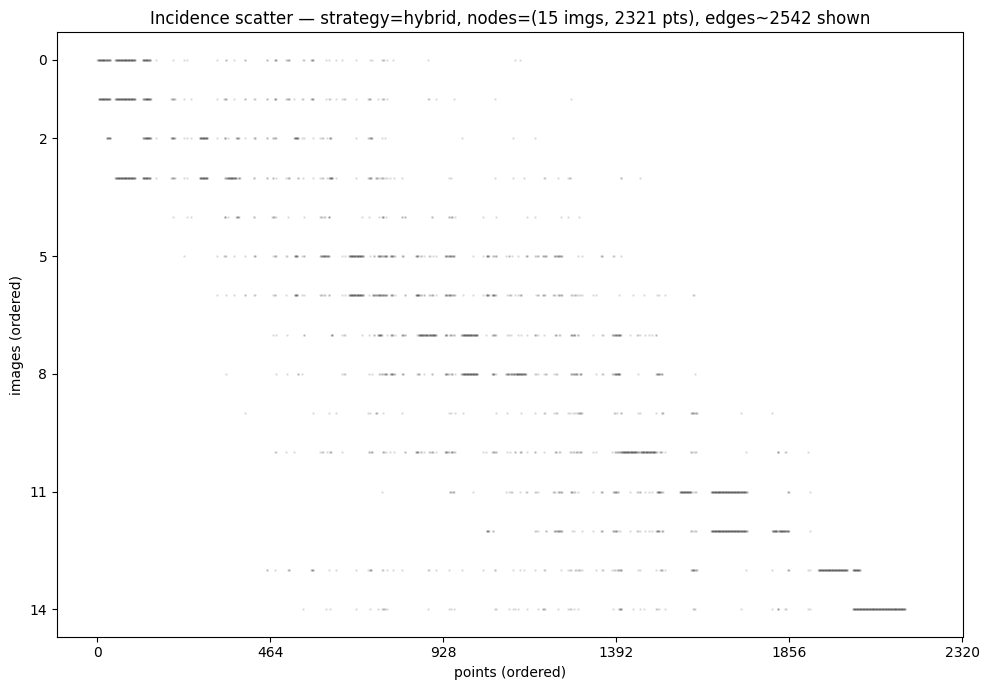

In [8]:
import numpy as np, matplotlib.pyplot as plt

# --- Config ---
ORDER_STRATEGY = 'hybrid'   # 'degree' | 'barycentric' | 'hybrid'
N_ORDER_ITERS = 3           # refinement passes for barycentric/hybrid
MAX_NEIGHBORS_PER_NODE = 200
MAX_N_IMGS = 2000           # cap number of images for visualization (top-degree if capped)
MAX_N_PTS  = 10000          # cap number of points  for visualization (top-degree if capped)
MAX_EDGES_SHOW = 500_000    # cap number of plotted edges
RANDOM_SEED = 0

rng = np.random.default_rng(RANDOM_SEED)

# --- Collect nodes ---
imgs = list(reconstruction.images.values())
pts_ids = list(reconstruction.points3D.keys())
ix = {im.image_id: i for i, im in enumerate(imgs)}
px = {pid: j for j, pid in enumerate(pts_ids)}
n_i, n_p = len(imgs), len(pts_ids)

# --- Build adjacency (full, then we will downselect) ---
img_to_pts = [[] for _ in range(n_i)]
pt_to_imgs = [[] for _ in range(n_p)]
for im in imgs:
    i = ix[im.image_id]
    for p2d in im.points2D:
        pid = p2d.point3D_id
        if pid != -1 and pid in px:
            j = px[pid]
            if len(img_to_pts[i]) < MAX_NEIGHBORS_PER_NODE:
                img_to_pts[i].append(j)
            if len(pt_to_imgs[j]) < MAX_NEIGHBORS_PER_NODE:
                pt_to_imgs[j].append(i)

# degrees on full sets
full_deg_i = np.array([len(nbrs) for nbrs in img_to_pts])
full_deg_p = np.array([len(nbrs) for nbrs in pt_to_imgs])

# --- Select a manageable subset (top-degree if needed) ---
if n_i > MAX_N_IMGS:
    sel_i = np.argsort(-full_deg_i)[:MAX_N_IMGS]
else:
    sel_i = np.arange(n_i)
if n_p > MAX_N_PTS:
    sel_p = np.argsort(-full_deg_p)[:MAX_N_PTS]
else:
    sel_p = np.arange(n_p)
sel_i_set = set(sel_i.tolist())
sel_p_set = set(sel_p.tolist())

# maps from original indices to compact [0..m_i) / [0..m_p)
map_i = {old_i: k for k, old_i in enumerate(sel_i)}
map_p = {old_j: k for k, old_j in enumerate(sel_p)}

# compact adjacency for selected nodes
m_i, m_p = len(sel_i), len(sel_p)
img_to_pts_c = [[] for _ in range(m_i)]
pt_to_imgs_c = [[] for _ in range(m_p)]
for old_i in sel_i:
    ci = map_i[old_i]
    for old_j in img_to_pts[old_i]:
        if old_j in sel_p_set:
            cj = map_p[old_j]
            img_to_pts_c[ci].append(cj)
            pt_to_imgs_c[cj].append(ci)

# degrees on compact sets
deg_i = np.array([len(nbrs) for nbrs in img_to_pts_c])
deg_p = np.array([len(nbrs) for nbrs in pt_to_imgs_c])

# --- Ordering strategies ---
def positions_from_order(order, m):
    pos = np.empty(m, dtype=float)
    pos[order] = np.linspace(0.0, 1.0, m, endpoint=False)
    return pos

def order_degree(deg):
    return np.argsort(-deg)  # descending degree

def order_barycentric(img_to_pts, pt_to_imgs, m_i, m_p, iters=2):
    Xi = np.linspace(0.0, 1.0, max(m_i, 1), endpoint=False)[:m_i]
    Xp = np.linspace(0.0, 1.0, max(m_p, 1), endpoint=False)[:m_p]
    for _ in range(iters):
        if m_i:
            scores_i = np.array([
                np.mean(Xp[nbrs]) if len(nbrs) else Xi[i]
                for i, nbrs in enumerate(img_to_pts)
            ])
            order_i = np.argsort(scores_i)
            Xi = positions_from_order(order_i, m_i)
        if m_p:
            scores_p = np.array([
                np.mean(Xi[nbrs]) if len(nbrs) else Xp[j]
                for j, nbrs in enumerate(pt_to_imgs)
            ])
            order_p = np.argsort(scores_p)
            Xp = positions_from_order(order_p, m_p)
    order_i = np.argsort(Xi)
    order_p = np.argsort(Xp)
    return order_i, order_p

def order_hybrid(img_to_pts, pt_to_imgs, deg_i, deg_p, m_i, m_p, iters=3):
    # seed by degree for points (columns), then barycentric passes
    order_p = order_degree(deg_p)
    Xp = positions_from_order(order_p, m_p)
    Xi = np.linspace(0.0, 1.0, max(m_i, 1), endpoint=False)[:m_i]
    for _ in range(iters):
        if m_i:
            scores_i = np.array([
                np.mean(Xp[nbrs]) if len(nbrs) else Xi[i]
                for i, nbrs in enumerate(img_to_pts)
            ])
            order_i = np.argsort(scores_i)
            Xi = positions_from_order(order_i, m_i)
        if m_p:
            scores_p = np.array([
                np.mean(Xi[nbrs]) if len(nbrs) else Xp[j]
                for j, nbrs in enumerate(pt_to_imgs)
            ])
            order_p = np.argsort(scores_p)
            Xp = positions_from_order(order_p, m_p)
    order_i = np.argsort(Xi)
    order_p = np.argsort(Xp)
    return order_i, order_p

if ORDER_STRATEGY == 'degree':
    order_i = order_degree(deg_i)
    order_p = order_degree(deg_p)
elif ORDER_STRATEGY == 'barycentric':
    order_i, order_p = order_barycentric(img_to_pts_c, pt_to_imgs_c, m_i, m_p, iters=N_ORDER_ITERS)
else:  # 'hybrid'
    order_i, order_p = order_hybrid(img_to_pts_c, pt_to_imgs_c, deg_i, deg_p, m_i, m_p, iters=N_ORDER_ITERS)

# inverse order maps to positions in the reordered matrix
inv_i = np.empty(m_i, dtype=int); inv_i[order_i] = np.arange(m_i)
inv_p = np.empty(m_p, dtype=int); inv_p[order_p] = np.arange(m_p)

# --- Build edge coordinates (rows, cols) in the reordered space ---
rows, cols = [], []
for ci, nbrs in enumerate(img_to_pts_c):
    if not nbrs: continue
    ri = inv_i[ci]
    for cj in nbrs:
        rows.append(ri)
        cols.append(inv_p[cj])
rows = np.array(rows, dtype=int)
cols = np.array(cols, dtype=int)

# sample edges if too many
E = len(rows)
if E > MAX_EDGES_SHOW:
    keep = rng.choice(E, size=MAX_EDGES_SHOW, replace=False)
    rows = rows[keep]
    cols = cols[keep]

# --- Plot incidence scatter (images x points) ---
plt.figure(figsize=(10, 7))
plt.scatter(cols, rows, s=1, c='k', alpha=0.08)
plt.gca().invert_yaxis()
plt.xlabel('points (ordered)')
plt.ylabel('images (ordered)')
plt.title(f"Incidence scatter — strategy={ORDER_STRATEGY}, nodes=({m_i} imgs, {m_p} pts), edges~{len(rows)} shown")
# tidy axes ticks
xticks = np.linspace(0, m_p-1, num=6, dtype=int) if m_p > 1 else np.array([0])
yticks = np.linspace(0, m_i-1, num=6, dtype=int) if m_i > 1 else np.array([0])
plt.xticks(xticks)
plt.yticks(yticks)
plt.tight_layout()
